In [1]:
# This is the most up to date code from langchain. Others we have been using, like the ones from the book of Alammar,
# still work but are a bit out of date


#In many Q&A applications we want to allow the user to have a back-and-forth conversation, meaning the application needs some sort of "memory" of past 
# questions and answers, and some logic for incorporating those into its current thinking.

#Part 2 (this guide) extends the implementation to accommodate conversation-style interactions and multi-step retrieval processes. 

#Here we focus on adding logic for incorporating historical messages. This involves the management of a chat history.

#We will cover two approaches:

    #Chains, in which we execute at most one retrieval step;
    #Agents, in which we give an LLM discretion to execute multiple retrieval steps.

https://python.langchain.com/docs/tutorials/qa_chat_history/

# Loading of documents and other things needed for both approaches

In [2]:
from langchain_community.document_loaders import PyMuPDFLoader 
from pathlib import Path
#from langchain_community.document_loaders.parsers import TesseractBlobParser #In case there are images with text

from langchain_text_splitters import RecursiveCharacterTextSplitter 
#I decided not to use RecursiveCharacterTextSplitter. Maybe it is useful for regular documents, but not for boardgames rulebooks
#Character was also not great since the first splitting hierarchy is /n/n. Decided to keep it with recursive

import os
from dotenv import load_dotenv
load_dotenv()  # Loads from .env

from langchain.chat_models import init_chat_model
COHERE_API_KEY=os.getenv("COHERE_TOKEN")
os.environ["COHERE_API_KEY"]=COHERE_API_KEY 

from langchain_cohere import CohereEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore

In [3]:
try:
    # Works in regular Python scripts
    base_dir = Path(__file__).resolve().parent.parent
except NameError:
    # Fallback for Jupyter notebooks and interactive shells
    base_dir = Path().resolve().parent

In [4]:
embeddings = CohereEmbeddings(model="embed-v4.0")

# For this to work the cohere api key needs to be as env variable with the name COHERE_API_KEY
model = init_chat_model("command-a-03-2025", model_provider="cohere")

In [5]:
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

In [6]:
#This starts a local (embedded) Qdrant instance, which stores data in /tmp/langchain_qdrant.
#No server is needed — it’s just a file-based vector database running in your Python environment

path_qdrant_vector_store = base_dir / "data" /  "qdrant"

client = QdrantClient(path=path_qdrant_vector_store)



In [ ]:
#This creates a collection (think: like a table) in Qdrant named "demo_collection"
# Done only if collection does not exist. Otherwise it will throw an error
client.create_collection(
    collection_name="document_embeddings",
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)

ValueError: Collection document_embeddings already exists

In [7]:
vector_store = QdrantVectorStore(
    client=client,
    collection_name="document_embeddings",
    embedding=embeddings,
)

In [ ]:
#vector_store = InMemoryVectorStore(embeddings)


In [5]:
#Change prints for logging

In [8]:


path_rules_pdf = base_dir / "data" / 'raw-rulebooks' 

print(path_rules_pdf)

C:\Users\Carlos Ivan\Documents\Projects\boardgames-assistant\data\raw-rulebooks


### Load documents

In [10]:
pdf_files = [f.name for f in path_rules_pdf.glob("*.pdf")]
print(len(pdf_files))
print(pdf_files)

24
['In_The_Footsteps_Of_Marco_Polo_-_English_Overview_Cards.pdf', 'LlamaLand_Player_Aid_(English)_version_2.pdf', 'LlamaLand_Rules_EN.pdf', 'Memoir_44_-_a_beginners_reference.pdf', 'memoir_44_rules_part1_en.pdf', 'Memoir_44_Unofficial_FAQ_v12.pdf', 'munchkindisneyrules.pdf', 'MunchkinDisney_Instr.pdf', 'MYSTERIUM_PARK_RULES_EN_BD.pdf', 'Mysterium_Park_Rules_Summary_unnofficial.pdf', 'Paleo_FAQ_11-12-20_ENG.pdf', 'Paleo_Rulebook_EN_compressed.pdf', 'pandemic season 1 rules.pdf', 'partners.pdf', 'Partners_rules.pdf', 'Power-Grid-Recharged-Rules.pdf', 'skull_king_rulebook_optimized.pdf', 'Take-5-or-6-Nimmt-Rules.pdf', 'Take_5_6nimmt30_rules_english.pdf', 'The_Crew_Demo_Sheet.pdf', 'The_Crew_Manual.pdf', 'Tureluurs unofficial rules.pdf', 'Voyages Of Marco Polo - English Rules V3.pdf', 'Voyages_Of_Marco_Polo_-_FAQ_and_Errata_V2.pdf']


In [29]:
for a_pdf in pdf_files[:5]:

    a_loader = PyMuPDFLoader(path_rules_pdf / a_pdf,
                        #mode="single", # Comment this to have different documents per page #The splitter we use appends pages, and it needs to be done without single
                        #extract_tables="markdown", #adds tables at the end of the page
                        #images_inner_format="html-img",  #Did not see huge improvements when using it 
                        #images_parser=TesseractBlobParser(),
                        )
    
    a_doc = a_loader.load()
    # It took less than 1 second without tables
    # extract_tables takes significatnly longer than without it (20 seconds)
    # with tables and images using tesseract (good quality) it took 29 seconds

    print(f'Number of characters of {a_pdf}: {sum([len(a.page_content) for a in a_doc])}') #Total characters

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1500,  # chunk size (characters)
        chunk_overlap=300,  # chunk overlap (characters)
        add_start_index=True,  # track index in original document
    )

    all_splits = text_splitter.split_documents(a_doc)
    print(f"Split blog post into {len(all_splits)} sub-documents.")

    # Append to each split name of pdf (in case metadata is not included in )
    for a_split in all_splits:
        # added to the chunks both the name of the rule book and the page from the chunk comes from (useful to ask in which page to find something) 
        a_split.page_content = 'Game: ' + a_pdf.split('.')[0] + f', page {a_split.metadata["page"]}' + '. Content: ' + a_split.page_content
        a_split.metadata['game']= a_pdf.split('.')[0] 

    # Add embeddings of the splits into the vector store
    _ = vector_store.add_documents(documents=all_splits)
    #print(f'Size of vector store until now: {len(vector_store.store.items())}') #Works for in-memory vector_store
    nr_vector_store_documents=client.count(collection_name=vector_store.collection_name).count  # Works for Qdrant vector_store
    print(f'Size of vector store until now: {nr_vector_store_documents}') # Works for Qdrant vector_store

Number of characters of In_The_Footsteps_Of_Marco_Polo_-_English_Overview_Cards.pdf: 4928
Split blog post into 5 sub-documents.
Size of vector store until now: 111
Number of characters of LlamaLand_Player_Aid_(English)_version_2.pdf: 0
Split blog post into 0 sub-documents.
Size of vector store until now: 111
Number of characters of LlamaLand_Rules_EN.pdf: 14940
Split blog post into 16 sub-documents.
Size of vector store until now: 127
Number of characters of Memoir_44_-_a_beginners_reference.pdf: 40175
Split blog post into 42 sub-documents.
Size of vector store until now: 169
Number of characters of memoir_44_rules_part1_en.pdf: 38777
Split blog post into 38 sub-documents.
Size of vector store until now: 207


In [8]:
client.count(collection_name=vector_store.collection_name).count


207

# Approach via Chains

I think that in order for a rag to store memory, we have to change the structure of our state to instead of context, query and answer, to just query and answer. And then we treat everything as if it was a regular chatbot, and add memory to it.

However, it seems that the tutorial wanted us to do that via tools (which are functions that the chatbot can decide to run if it thinks that they are useful in answering the query). Probably they forced us to do it like that to get more used to that approach, since Agents also work like that.

"Conversational experiences (history) can be naturally represented using a sequence of messages. In addition to messages from the user and assistant, retrieved documents and other artifacts can be incorporated into a message sequence via tool messages. This motivates us to represent the state of our RAG application using a sequence of messages."

In [ ]:
#Leveraging tool-calling to interact with a retrieval step has another benefit, which is that the query for the retrieval is generated by our model. (this
# means that the model will decide how to parse the inputs to the tool (function) it decides to use, which could this allow a model to rewrite user queries 
# into more effective ones)

In [ ]:
from langchain_core.tools import tool

#An agent decides which tool to use based on the tool's names, descriptions, and argument schemas
@tool(response_format="content_and_artifact") # This will make it possible for a chat model to call this function
def retrieve(query: str): # Before, retrieve received a State as input. Now only a string.
    """Retrieve information related to a query."""
    retrieved_docs = vector_store.similarity_search(query, k=4)
    serialized = "\n\n".join(  #The concatenation of docs as strings was done in the generate function before, and it did not include metadata
        (f"Content: {doc.page_content}") #I could modify this to only return useful metadata
        for doc in retrieved_docs 
    )
    print('Retrieval of data successful')
    return serialized, retrieved_docs  # if you use @tool(response_format="content_and_artifact"), you must return exactly a tuple of two elements

#First element → This is what will be used as the main textual output (like a summary or answer).
#Second element → This is any additional data (e.g. a document, list of sources, JSON, etc.) that might be useful for tracking, inspection, or chaining.


Our graph will consist of three nodes:

1- A node that fields the user input, either generating a query for the retriever or responding directly; **(this is cool and we did not have it before. an answer can now come from the context, or from the previous messages. In the previous implementation, no matter how much prompt engineering we did, even if we added memory to the rag, we would always be extracting info from the vector space and adding them into the query. Now only when the history does not know the answer)**

2- A node for the retriever tool that executes the retrieval step;

3- A node that generates the final response using the retrieved context.

In [ ]:


#output_1= query_or_respond({"messages": [{"role": "user", "content": 'How do you win at paleo?'}]})

#input_for_retrieve = output_1['messages'][0].additional_kwargs['tool_calls'][0]['function']['arguments']

#retrieve(input_for_retrieve)

C:\Users\Carlos Ivan\AppData\Local\Temp\ipykernel_5796\1724599674.py:5: LangChainDeprecationWarning: The method `BaseTool.__call__` was deprecated in langchain-core 0.1.47 and will be removed in 1.0. Use :meth:`~invoke` instead.
  retrieve(input_for_retrieve)


{'messages': [AIMessage(content="I will search for 'how do you win at paleo?'", additional_kwargs={'id': '09060a47-eecb-4d7f-89ee-3e4a4523c932', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how do you win at paleo?'", 'tool_calls': [{'id': 'retrieve_g7vgxpxcapyv', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"How do you win at paleo?"}'}}], 'token_count': {'input_tokens': 1433.0, 'output_tokens': 53.0}}, response_metadata={'id': '09060a47-eecb-4d7f-89ee-3e4a4523c932', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how do you win at paleo?'", 'tool_calls': [{'id': 'retrieve_g7vgxpxcapyv', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"How do you win at paleo?"}'}}], 'token_count': {'input_tokens': 1433.0, 'output_tokens': 53.0}}, id='run--5b6148be-8308-4228-aaaa-bf3c6a54f933-0', tool_calls=[{'name': 'retrieve', 'args': {'query': 'How do you win at paleo?'}, 'id': 'retrieve_g7vgxpxcapyv', 'type

"Source: {'producer': 'macOS Version 10.14.6 (Build 18G6020) Quartz PDFContext', 'creator': 'Adobe InDesign 15.1 (Windows)', 'creationdate': '2020-10-21T20:15:10+00:00', 'source': 'C:\\\\Users\\\\Carlos Ivan\\\\Documents\\\\Projects\\\\boardgames-assistant\\\\data\\\\raw-rulebooks\\\\Paleo_Rulebook_EN_compressed.pdf', 'file_path': 'C:\\\\Users\\\\Carlos Ivan\\\\Documents\\\\Projects\\\\boardgames-assistant\\\\data\\\\raw-rulebooks\\\\Paleo_Rulebook_EN_compressed.pdf', 'total_pages': 12, 'format': 'PDF 1.6', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2020-10-21T20:51:38+00:00', 'trapped': '', 'modDate': 'D:20201021205138Z', 'creationDate': 'D:20201021201510Z', 'page': 1, 'start_index': 1206, 'game': 'Paleo_Rulebook_EN_compressed'}\nContent: Game: Paleo_Rulebook_EN_compressed, page 1. Content: look at the cards too closely when you sort them. How to sort the cards is described in \n“Card Setup” on the right.\n• During most games, you will use only 2 of the 10 i

In [ ]:
# We generate these nodes here

from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import MessagesState, StateGraph
from langgraph.prebuilt import ToolNode



# Node 1: Generate an AIMessage that may include a tool-call to be sent.
def query_or_respond(state: MessagesState):
    """Generate tool call for retrieval or respond."""
    llm_with_tools = model.bind_tools([retrieve]) # Tells the chat model it can use the retrieve tool
    response = llm_with_tools.invoke(state["messages"]) 
    #response is an AIMessage object with the content of the message and some metadata
    # This metadata also says if you most call a Tool or not, and which function
    # MessagesState appends messages to state instead of overwriting
    output = {"messages": [response]}
    print(output)
    return output


# Node 2: Execute the retrieval.
#ToolNode executes the tool and adds the result as a ToolMessage to the state. (This is important info)
#I think this addition only happens when running it inside a graph for a particular state, not if you run it independently
tools = ToolNode([retrieve])


# Node 3: Generate a response using the retrieved content. This will only be run if we retrieved data from the vector_store
def generate(state: MessagesState): #This state contains the original query as a human message + the context from the retriever as an ai message
    """Generate answer."""
    # Get generated ToolMessages
    recent_tool_messages = []
    for message in reversed(state["messages"]):
        #print(message.content) #Useful to see what is appended in the message
        if message.type == "tool":
            recent_tool_messages.append(message.content) #appends only tool messages'content (not metadata!) (outputs from the retriever)
        else:
            break
    tool_messages = recent_tool_messages[::-1] #orders them from first to last 

    # Format into prompt
    docs_content = "\n\n".join(doc for doc in tool_messages) # I dont see the need of this if we already joined contexts in tools. 
    #maybe try using tools and see if it works or not?
    system_message_content = (
        "You are an assistant for question-answering tasks. "
        "Use the following pieces of retrieved context to answer the question. "
        "If you don't know the answer, just say that you don't know, don't try to make up an answer."
        "Use between three to 5 sentences maximum and keep the answer concise."
        "\n\n"
        f"{docs_content}"
    )
    conversation_messages = [
        message
        for message in state["messages"]
        if message.type in ("human", "system")
        or (message.type == "ai" and not message.tool_calls) #excludes ai messages from the retriever (outputs of the retriever are already added in system_message_content)
    ]
    prompt = [SystemMessage(system_message_content)] + conversation_messages
    print(f'Prompt for generate function: {prompt}' )

    # Run
    response = model.invoke(prompt)
    return {"messages": [response]} # MessagesState appends messages to state instead of overwriting

In [94]:
from langgraph.graph import MessagesState, StateGraph
from langgraph.graph import END
from langgraph.prebuilt import  tools_condition
from langgraph.checkpoint.memory import MemorySaver




graph_builder = StateGraph(MessagesState)



graph_builder.add_node(query_or_respond)
graph_builder.add_node(tools)
graph_builder.add_node(generate)

graph_builder.set_entry_point("query_or_respond")
graph_builder.add_conditional_edges(
    "query_or_respond",
    tools_condition,
    {END: END, "tools": "tools"},
)
graph_builder.add_edge("tools", "generate")
graph_builder.add_edge("generate", END)

memory = MemorySaver()


graph = graph_builder.compile(checkpointer=memory)


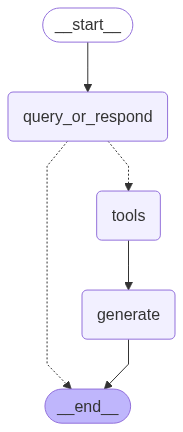

In [73]:
# To visualize flow: 
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

### Testing

In [95]:


# Specify an ID for the thread
config = {"configurable": {"thread_id": "abc123"}}

In [96]:
input_message='How do you win at power grid?'

graph.invoke({"messages": [{"role": "user", "content": input_message}]}, config=config)

{'messages': [AIMessage(content="I will search for 'how to win at power grid?'", additional_kwargs={'id': '07ce7759-dd3e-468e-826c-e3eece9b7445', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how to win at power grid?'", 'tool_calls': [{'id': 'retrieve_mg8r3gw28amb', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how to win at power grid?"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 53.0}}, response_metadata={'id': '07ce7759-dd3e-468e-826c-e3eece9b7445', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how to win at power grid?'", 'tool_calls': [{'id': 'retrieve_mg8r3gw28amb', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how to win at power grid?"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 53.0}}, id='run--c0b5526e-0e7f-4d0f-b578-0f69044da190-0', tool_calls=[{'name': 'retrieve', 'args': {'query': 'how to win at power grid?'}, 'id': 'retrieve_mg8r3gw28amb',

{'messages': [HumanMessage(content='How do you win at power grid?', additional_kwargs={}, response_metadata={}, id='a179526b-07a7-455b-ab55-67dae0551d25'),
  AIMessage(content="I will search for 'how to win at power grid?'", additional_kwargs={'id': '07ce7759-dd3e-468e-826c-e3eece9b7445', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how to win at power grid?'", 'tool_calls': [{'id': 'retrieve_mg8r3gw28amb', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how to win at power grid?"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 53.0}}, response_metadata={'id': '07ce7759-dd3e-468e-826c-e3eece9b7445', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how to win at power grid?'", 'tool_calls': [{'id': 'retrieve_mg8r3gw28amb', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how to win at power grid?"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 53.0}}, id='run--c0b5526e

In [97]:
#input_message='How do you win at paleo?'
input_message='What was my last question?'
#input_message='Good morning Cohere chatbot!'
#input_message='Up to how many players can Monopoly be played?'


graph.invoke({"messages": [{"role": "user", "content": input_message}]}, config=config)

{'messages': [AIMessage(content='Your last question was: "How do you win at power grid?"', additional_kwargs={'id': 'dbfb71c3-d45f-4834-af4c-175d0e7917b5', 'finish_reason': 'COMPLETE', 'content': 'Your last question was: "How do you win at power grid?"', 'token_count': {'input_tokens': 2798.0, 'output_tokens': 16.0}}, response_metadata={'id': 'dbfb71c3-d45f-4834-af4c-175d0e7917b5', 'finish_reason': 'COMPLETE', 'content': 'Your last question was: "How do you win at power grid?"', 'token_count': {'input_tokens': 2798.0, 'output_tokens': 16.0}}, id='run--93d45e8e-103b-436f-893a-d367cd43e4d6-0', usage_metadata={'input_tokens': 2798, 'output_tokens': 16, 'total_tokens': 2814})]}


{'messages': [HumanMessage(content='How do you win at power grid?', additional_kwargs={}, response_metadata={}, id='a179526b-07a7-455b-ab55-67dae0551d25'),
  AIMessage(content="I will search for 'how to win at power grid?'", additional_kwargs={'id': '07ce7759-dd3e-468e-826c-e3eece9b7445', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how to win at power grid?'", 'tool_calls': [{'id': 'retrieve_mg8r3gw28amb', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how to win at power grid?"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 53.0}}, response_metadata={'id': '07ce7759-dd3e-468e-826c-e3eece9b7445', 'finish_reason': 'TOOL_CALL', 'tool_plan': "I will search for 'how to win at power grid?'", 'tool_calls': [{'id': 'retrieve_mg8r3gw28amb', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"how to win at power grid?"}'}}], 'token_count': {'input_tokens': 1434.0, 'output_tokens': 53.0}}, id='run--c0b5526e

In [ ]:
input_message = "How do you win at Power grid?"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
    config=config
):
    step["messages"][-1].pretty_print()

# It does not check again the vector store because it already knows that answer from the chat history

================================ Human Message =================================

How do you win at Power grid?
{'messages': [AIMessage(content="To win at Power Grid, the game ends after Phase 4 (Build Houses) when at least one player has connected the required number of cities in their network. In Phase 5 (Bureaucracy), players determine who can supply electricity to the most cities using their resources and power plants. The player who powers the most cities wins. If there's a tie, the player with the most remaining money wins. It's important to note that the player who ends the game by connecting cities may not necessarily win if they cannot power all their cities due to insufficient power plant capacity or resources.", additional_kwargs={'id': 'dc0123ce-10c4-4a8c-9287-a314a1e90a95', 'finish_reason': 'COMPLETE', 'content': "To win at Power Grid, the game ends after Phase 4 (Build Houses) when at least one player has connected the required number of cities in their network. In Phase 

# Via Agents

Agents leverage the reasoning capabilities of LLMs to make decisions during execution. Although their behavior is less predictable than the above "chain", they are able to execute multiple retrieval steps in service of a query, or iterate on a single search.

Below we assemble a minimal RAG agent. Using LangGraph's pre-built ReAct agent constructor, we can do this in one line.

In [99]:
from langgraph.prebuilt import create_react_agent

agent_executor = create_react_agent(model, [retrieve], checkpointer=memory)

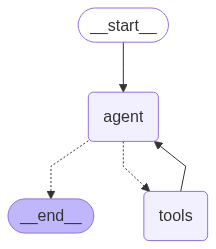

In [ ]:
display(Image(agent_executor.get_graph().draw_mermaid_png()))
# Wow. Impressive. Here we have not even said that the agent must summarize the outputs of the tools. Mmmm. We still need to add those details like 
# 5 sentence maximum. Where do we do that?
# 
# #The key difference from our earlier implementation is that instead of a final generation step that ends the run, here the tool invocation loops back 
# to the original LLM call. 
# I see. So that means that the rules about the max 5 sentences should be given by the human in the question.

#The agent will break out the question and access the tools as many times as needed! :D


In [120]:
config = {"configurable": {"thread_id": "def236"}}
input_message = (
    "Maximum number of players that powergrid can be played?\n\n"
    "Once you get the answer, check the same but for Paleo."
)

agent_executor.invoke({"messages": [{"role": "user", "content": input_message}]}, config=config)

Retrieval of data successful
Retrieval of data successful


{'messages': [HumanMessage(content='Maximum number of players that powergrid can be played?\n\nOnce you get the answer, check the same but for Paleo.', additional_kwargs={}, response_metadata={}, id='64853ed0-830d-4d85-a9f6-7a727bfd9492'),
  AIMessage(content='I will search for the maximum number of players that powergrid can be played with. Then I will search for the same but for Paleo.', additional_kwargs={'id': 'e73fcfdd-bff3-4e21-bdf8-3c48fc16d504', 'finish_reason': 'TOOL_CALL', 'tool_plan': 'I will search for the maximum number of players that powergrid can be played with. Then I will search for the same but for Paleo.', 'tool_calls': [{'id': 'retrieve_bzqn0x6d1xj5', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"Maximum number of players that powergrid can be played?"}'}}, {'id': 'retrieve_z04rktc1y5er', 'type': 'function', 'function': {'name': 'retrieve', 'arguments': '{"query":"Maximum number of players that Paleo can be played?"}'}}], 'token_count

In [ ]:
config = {"configurable": {"thread_id": "def235"}}

#input_message = (
#    "Maximum number of players that powergrid can be played?\n\n"
#    "Once you get the answer, check the same but for Paleo."
#)
input_message = "Maximum number of players that powergrid can be played?\n\n Once you get the answer, check the same but for Paleo."
# Both input_message formats are allowed

for event in agent_executor.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
    config=config,
):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Maximum number of players that powergrid can be played?

 Once you get the answer, check the same but for Paleo.
================================== Ai Message ==================================

I will first search for the maximum number of players that powergrid can be played with. Once I have this answer, I will search for the same information for Paleo.
Tool Calls:
  retrieve (retrieve_e1cn24m129da)
 Call ID: retrieve_e1cn24m129da
  Args:
    query: Maximum number of players that powergrid can be played?
  retrieve (retrieve_18mzxptkhryq)
 Call ID: retrieve_18mzxptkhryq
  Args:
    query: Maximum number of players that Paleo can be played?
Retrieval of data successful
Retrieval of data successful
================================= Tool Message =================================
Name: retrieve

Content: Game: Paleo_Rulebook_EN_compressed, page 1. Content: during the same action, the players win the game.


In [ ]:
#This is nice because the prompt structure is declared before a particular question

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import SystemMessage, HumanMessage

prompt_template = ChatPromptTemplate.from_messages(
    [
        ("system",
         "You are an assistant for question-answering tasks. "
         "Use the tools to retrieve context to answer the question. "
         "If you don't know the answer, just say that you don't know, don't try to make up an answer. "
         "Use between three to 5 sentences maximum and keep the answer concise.\n\n"
         ),
        ("human", "{question}")
    ]
)




In [ ]:
input_message = (
    "Maximum number of players that powergrid can be played?\n\n"
    "Once you get the answer, check the same but for Paleo."
)

input_message = "Maximum number of players that powergrid and paleo can be played ?" # This question is too difficult for the
#agent to divide the task. Instead, it did all in a single retrieval


prompt = prompt_template.invoke({"question": input_message})

prompt.messages

[SystemMessage(content="You are an assistant for question-answering tasks. Use the tools to retrieve context to answer the question. If you don't know the answer, just say that you don't know, don't try to make up an answer. Use between three to 5 sentences maximum and keep the answer concise.\n\n", additional_kwargs={}, response_metadata={}),
 HumanMessage(content='Maximum number of players that powergrid and paleo can be played ?', additional_kwargs={}, response_metadata={})]

In [136]:
prompt

ChatPromptValue(messages=[SystemMessage(content="You are an assistant for question-answering tasks. Use the tools to retrieve context to answer the question. If you don't know the answer, just say that you don't know, don't try to make up an answer. Use between three to 5 sentences maximum and keep the answer concise.\n\n", additional_kwargs={}, response_metadata={}), HumanMessage(content='Maximum number of players that powergrid and paleo can be played ?', additional_kwargs={}, response_metadata={})])

In [137]:
config = {"configurable": {"thread_id": "def240"}}


# Both presentations give the same because they are the same (see above)
#agent_executor.invoke({"messages": prompt.messages}, config=config)
agent_executor.invoke(prompt, config=config)

Retrieval of data successful


{'messages': [SystemMessage(content="You are an assistant for question-answering tasks. Use the tools to retrieve context to answer the question. If you don't know the answer, just say that you don't know, don't try to make up an answer. Use between three to 5 sentences maximum and keep the answer concise.\n\n", additional_kwargs={}, response_metadata={}, id='b2aa0a20-c9c1-4e28-b3c7-c05ae4ada60a'),
  HumanMessage(content='Maximum number of players that powergrid and paleo can be played ?', additional_kwargs={}, response_metadata={}, id='d7ded4a4-8350-4e37-b5d3-fd5ae6f47d17'),
  AIMessage(content='I will search for the maximum number of players that powergrid and paleo can be played.', additional_kwargs={'id': '63104bd5-332b-48bb-b8fd-037c2986b717', 'finish_reason': 'TOOL_CALL', 'tool_plan': 'I will search for the maximum number of players that powergrid and paleo can be played.', 'tool_calls': [{'id': 'retrieve_3te7r17bx0qn', 'type': 'function', 'function': {'name': 'retrieve', 'argume

In [ ]:
#This is not nice because the prompt structure is created after the question

question= "How long does powergrid takes? Once you get the answer, check how long does paleo take."

system_message_content = (
        "You are an assistant for question-answering tasks. "
        "Use the tools to retrieve context to answer the question. "
        "If you don't know the answer, just say that you don't know, don't try to make up an answer."
        "Use between three to 5 sentences maximum and keep the answer concise."
        "\n\n"
    )

prompt = [SystemMessage(system_message_content),
          HumanMessage(question)]


prompt

[SystemMessage(content="You are an assistant for question-answering tasks. Use the tools to retrieve context to answer the question. If you don't know the answer, just say that you don't know, don't try to make up an answer.Use between three to 5 sentences maximum and keep the answer concise.\n\n", additional_kwargs={}, response_metadata={}),
 HumanMessage(content='How long does powergrid takes? Once you get the answer, check how long does paleo take.', additional_kwargs={}, response_metadata={})]

In [131]:
config = {"configurable": {"thread_id": "def239"}}


# Both presentations give the same because they are the same (see above)
agent_executor.invoke({"messages": prompt}, config=config)

ValueError: The last message is not an ToolMessage or HumanMessage